# Dropout experiment

In [ ]:
# DATA_DIR = DATA_DIR

TRAIN_DIR = DATA_DIR / 'train'
VALID_DIR = DATA_DIR / 'valid'
TEST_DIR = DATA_DIR / 'test'
NOISE_DIR = DATA_DIR / '_background_noise_'

print("Train:", len(list(TRAIN_DIR.rglob("*.wav"))))
print("Valid:", len(list(VALID_DIR.rglob("*.wav"))))

Train: 51486
Valid: 6828


In [ ]:
from pathlib import Path
import torch
import numpy as np
import random
import pandas as pd
import gc
import itertools

from data.utils import get_datasets, precompute_features
from data.dataset import CachedDataset
from data.transforms import FeatureConfig

from models.train import train, predict
from models.evaluate import evaluate
from models.transformer import Transformer
from models.cnn_transformer import CNNTransformer
from models.utils import set_seed

from plots import (
    plot_f1_training_curves,
    build_summary_df,
    plot_summary_table,
    plot_metrics_comparison,
    plot_f1_comparison,
    plot_confusion_matrix
)

if torch.cuda.is_available():
    device = torch.device('cuda')
elif torch.backends.mps.is_available():
    device = torch.device('mps')
else:
    device = torch.device('cpu')

print("Using device:", device)

Using device: cuda


## MEL

In [ ]:
train_ds, valid_ds, test_ds = get_datasets(
    data_format="mel",
    train_path=TRAIN_DIR,
    valid_path=VALID_DIR,
    test_path=TEST_DIR,
)

In [ ]:
CACHE_DIR = Path("/kaggle/working/cache_hparams_mel")

precompute_features(train_ds, CACHE_DIR / "train")
precompute_features(valid_ds, CACHE_DIR / "valid")
precompute_features(test_ds, CACHE_DIR / "test")

train_ds_cached = CachedDataset(CACHE_DIR / "train")
valid_ds_cached = CachedDataset(CACHE_DIR / "valid")
test_ds_cached = CachedDataset(CACHE_DIR / "test")

  0%|          | 0/51486 [00:00<?, ?it/s]

Saved 51486 samples to /kaggle/working/cache_hparams_mel/train


  0%|          | 0/6828 [00:00<?, ?it/s]

Saved 6828 samples to /kaggle/working/cache_hparams_mel/valid


  0%|          | 0/6865 [00:00<?, ?it/s]

Saved 6865 samples to /kaggle/working/cache_hparams_mel/test


In [ ]:
def cnn_transformer_factory(repr_name="mel", dropout=0.1):
    n_features = 40 if repr_name == "mfcc" else 64

    return CNNTransformer(
        n_features=n_features,
        n_timesteps=101,
        num_classes=12,
        base_channels=32,
        d_model=128,
        nhead=4,
        num_layers=4,
        dropout=dropout,
        pooling="mean",
    )

In [ ]:
DROPOUTS = [0.0, 0.1, 0.2, 0.3]
SEEDS = [0, 1, 2]
EPOCHS = 30

In [ ]:
LR = 1e-3
BATCH_SIZE = 256

In [ ]:
DROPOUT_MEL_SAVE_PATH = "/kaggle/working/dropout_experiment_mel.csv"

def dropout_experiment_mel(dropout_values, seeds=[0, 1, 2], epochs=30, lr=1e-3, batch_size=256):
    results = {}
    rows = []

    for dropout in dropout_values:
        results[dropout] = {}

        for seed in seeds:
            print(f"\nDropout={dropout} | seed={seed}")

            set_seed(seed)

            model = cnn_transformer_factory(
                repr_name="mel",
                dropout=dropout,
            ).to(device)

            model, history = train(
                model,
                train_ds_cached,
                valid_ds_cached,
                epochs=epochs,
                batch_size=batch_size,
                lr=lr,
                device=device,
            )

            best_valid_acc = max(history["valid_acc"])
            best_valid_macro_f1 = max(history["valid_f1"])

            results[dropout][seed] = {
                "history": history,
                "valid_acc": best_valid_acc,
                "valid_macro_f1": best_valid_macro_f1,
                "test_macro_f1": best_valid_macro_f1,
            }

            rows.append({
                "dropout": dropout,
                "seed": seed,
                "lr": lr,
                "batch_size": batch_size,
                "best_valid_acc": best_valid_acc,
                "best_valid_macro_f1": best_valid_macro_f1,
            })

            pd.DataFrame(rows).to_csv(DROPOUT_MEL_SAVE_PATH, index=False)

            del model
            torch.cuda.empty_cache()
            gc.collect()

    return results, pd.DataFrame(rows)

In [ ]:
dropout_mel_results, df_dropout_mel = dropout_experiment_mel(
    dropout_values=DROPOUTS,
    seeds=SEEDS,
    epochs=EPOCHS,
    lr=LR,
    batch_size=BATCH_SIZE,
)

df_dropout_mel.sort_values("best_valid_macro_f1", ascending=False)


Dropout=0.0 | seed=0
Epoch 1/30 | Train Loss: 1.2159 | Valid Loss: 0.6727 | Valid Acc: 0.7846 | Valid Macro F1: 0.6265
Epoch 2/30 | Train Loss: 0.3341 | Valid Loss: 0.2845 | Valid Acc: 0.9088 | Valid Macro F1: 0.8634
Epoch 3/30 | Train Loss: 0.1769 | Valid Loss: 0.1772 | Valid Acc: 0.9423 | Valid Macro F1: 0.9075
Epoch 4/30 | Train Loss: 0.1320 | Valid Loss: 0.2315 | Valid Acc: 0.9323 | Valid Macro F1: 0.8955
Epoch 5/30 | Train Loss: 0.1037 | Valid Loss: 0.2248 | Valid Acc: 0.9304 | Valid Macro F1: 0.8784
Epoch 6/30 | Train Loss: 0.0970 | Valid Loss: 0.1657 | Valid Acc: 0.9486 | Valid Macro F1: 0.9222
Epoch 7/30 | Train Loss: 0.0785 | Valid Loss: 0.1608 | Valid Acc: 0.9527 | Valid Macro F1: 0.9277
Epoch 8/30 | Train Loss: 0.0717 | Valid Loss: 0.1548 | Valid Acc: 0.9525 | Valid Macro F1: 0.9258
Epoch 9/30 | Train Loss: 0.0660 | Valid Loss: 0.1344 | Valid Acc: 0.9627 | Valid Macro F1: 0.9398
Epoch 10/30 | Train Loss: 0.0567 | Valid Loss: 0.1585 | Valid Acc: 0.9552 | Valid Macro F1: 0.92

,dropout,seed,lr,batch_size,best_valid_acc,best_valid_macro_f1
7,0.2,1,0.001,256,0.971002,0.957273
5,0.1,2,0.001,256,0.971734,0.957140
8,0.2,2,0.001,256,0.971880,0.956811
11,0.3,2,0.001,256,0.970709,0.956134
6,0.2,0,0.001,256,0.970855,0.956097
10,0.3,1,0.001,256,0.970855,0.955672
9,0.3,0,0.001,256,0.970123,0.955311
2,0.0,2,0.001,256,0.969830,0.955174
3,0.1,0,0.001,256,0.968951,0.952286
0,0.0,0,0.001,256,0.969098,0.952219


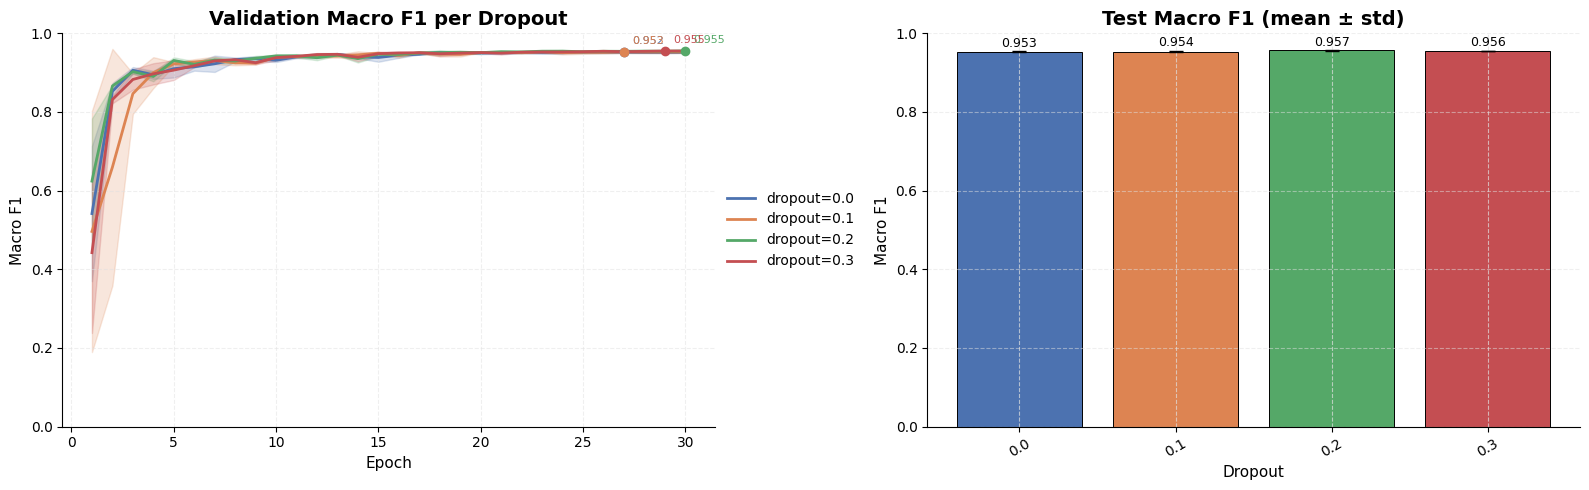

In [ ]:
plot_f1_comparison(
    dropout_mel_results,
    param_name="Dropout",
    param_name_short="dropout"
)